# 06 — Sentiment Analysis

Fetches recent financial news headlines via yfinance, scores them with FinBERT, and tests whether adding sentiment as a 12th feature improves model performance.

**Sentiment model:** ProsusAI/finbert — BERT fine-tuned on financial text  
**Score:** P(positive) - P(negative), range [-1, +1]  
**Comparison:** Logistic Regression (best classifier) and Random Forest (best regressor) with vs without sentiment  

**Note:** yfinance returns only recent articles (~10 per ticker). Most historical dates will be filled with 0.0 (neutral). Full historical coverage requires a paid news API.

In [1]:
!pip install transformers yfinance torch --quiet

In [2]:
import os
import time
import numpy as np
import pandas as pd
import yfinance as yf
import torch
import torch.nn.functional as F
import warnings
warnings.filterwarnings("ignore")

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (accuracy_score, f1_score,
                              mean_squared_error, mean_absolute_error)
import matplotlib.pyplot as plt

BASE_DIR     = "."
FEAT_DIR     = os.path.join(BASE_DIR, "data/features")
SENT_DIR     = os.path.join(BASE_DIR, "data/sentiment")
RESULTS_DIR  = os.path.join(BASE_DIR, "data/results")

TICKERS      = ["AAPL", "MSFT", "JPM", "GS", "JNJ", "PFE", "SPOT", "AMZN", "TSLA"]
FEATURE_COLS = [
    "SMA_5", "SMA_10", "SMA_20",
    "EMA_5", "EMA_10", "EMA_20",
    "RSI_14", "MACD", "MACD_Signal",
    "Volatility", "Volume_Change"
]
FEATURE_COLS_WITH_SENT = FEATURE_COLS + ["Sentiment_Score"]

os.makedirs(SENT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## 1. Load FinBERT

In [3]:
print("Loading FinBERT...")
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
finbert   = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")
finbert   = finbert.to(device)
finbert.eval()
print("FinBERT loaded. Labels: 0=positive, 1=negative, 2=neutral")


def score_headlines(headlines, batch_size=16):
    all_scores = []
    for i in range(0, len(headlines), batch_size):
        batch  = headlines[i: i + batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True,
                           max_length=512, return_tensors="pt").to(device)
        with torch.no_grad():
            probs = F.softmax(finbert(**inputs).logits, dim=-1)
        score = probs[:, 0].cpu().numpy() - probs[:, 1].cpu().numpy()
        all_scores.extend(score.tolist())
    return np.array(all_scores)


# Quick validation on sample headlines
test_headlines = [
    "Apple reports record quarterly earnings, beats analyst expectations",
    "Tesla stock plunges after CEO sells shares",
    "Federal Reserve holds interest rates steady",
]
test_scores = score_headlines(test_headlines)
for h, s in zip(test_headlines, test_scores):
    label = "POSITIVE" if s > 0.1 else ("NEGATIVE" if s < -0.1 else "NEUTRAL")
    print(f"  [{s:+.3f}] {label:<10}  {h[:60]}")

Loading FinBERT...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FinBERT loaded. Labels: 0=positive, 1=negative, 2=neutral
  [+0.871] POSITIVE    Apple reports record quarterly earnings, beats analyst expec
  [-0.932] NEGATIVE    Tesla stock plunges after CEO sells shares
  [-0.074] NEUTRAL     Federal Reserve holds interest rates steady


## 2. yfinance headline scraper

Fetches ticker-specific news from yfinance. Scores are lagged by 1 day before merging — today's news should predict tomorrow's return, not today's.

In [4]:
def fetch_yfinance_headlines(ticker):
    headlines_by_date = {}
    try:
        stock = yf.Ticker(ticker)
        news  = stock.news
        for article in news:
            title    = article.get("content", {}).get("title", "")
            pub_date = article.get("content", {}).get("pubDate", "")
            if not title or not pub_date:
                continue
            try:
                date_str = pd.Timestamp(pub_date).strftime("%Y-%m-%d")
            except Exception:
                continue
            headlines_by_date.setdefault(date_str, []).append(title)
    except Exception as e:
        print(f"    Warning: could not fetch news for {ticker}: {e}")
    return headlines_by_date


def build_sentiment_series(ticker, feature_dates):
    headlines_by_date = fetch_yfinance_headlines(ticker)
    daily_scores = {}
    for date_str, titles in headlines_by_date.items():
        if titles:
            daily_scores[date_str] = float(score_headlines(titles).mean())

    raw_series        = pd.Series(daily_scores)
    raw_series.index  = pd.to_datetime(raw_series.index)
    raw_series        = raw_series.sort_index()
    lagged            = raw_series.shift(1)
    aligned           = lagged.reindex(feature_dates, fill_value=0.0)
    return pd.DataFrame({"Sentiment_Score": aligned}, index=feature_dates)


print("Scraper defined.")

Scraper defined.


## 3. Fetch and score headlines for all tickers

In [5]:
print("Fetching headlines and scoring with FinBERT...")

for ticker in TICKERS:
    feat_df      = pd.read_csv(os.path.join(FEAT_DIR, f"{ticker}_features.csv"),
                               index_col="Date", parse_dates=True).sort_index()
    sentiment_df = build_sentiment_series(ticker, feat_df.index)
    sentiment_df.to_csv(os.path.join(SENT_DIR, f"{ticker}_sentiment.csv"))

    n_real = (sentiment_df["Sentiment_Score"] != 0.0).sum()
    n_fill = (sentiment_df["Sentiment_Score"] == 0.0).sum()
    real_scores = sentiment_df["Sentiment_Score"][sentiment_df["Sentiment_Score"] != 0.0]
    mean_real   = real_scores.mean() if len(real_scores) > 0 else float("nan")
    print(f"  {ticker:<5}  real: {n_real:>4}  neutral fill: {n_fill:>4}  mean (real): {mean_real:+.4f}")
    time.sleep(0.3)

print("\nSentiment scores saved to data/sentiment/")

Fetching headlines and scoring with FinBERT...


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

  AAPL   real:    1  neutral fill: 1311  mean (real): +nan
  MSFT   real:    1  neutral fill: 1311  mean (real): +nan
  JPM    real:    0  neutral fill: 1312  mean (real): +nan
  GS     real:    1  neutral fill: 1311  mean (real): +nan
  JNJ    real:    2  neutral fill: 1310  mean (real): +0.8891
  PFE    real:    2  neutral fill: 1310  mean (real): -0.0894
  SPOT   real:    2  neutral fill: 1310  mean (real): -0.0706
  AMZN   real:    2  neutral fill: 1310  mean (real): -0.8461
  TSLA   real:    3  neutral fill: 1309  mean (real): -0.0304

Sentiment scores saved to data/sentiment/


## 4. Merge sentiment with features

In [6]:
def load_with_sentiment(ticker):
    feat_df = pd.read_csv(os.path.join(FEAT_DIR, f"{ticker}_features.csv"),
                          index_col="Date", parse_dates=True).sort_index()
    sent_df = pd.read_csv(os.path.join(SENT_DIR, f"{ticker}_sentiment.csv"),
                          index_col="Date", parse_dates=True).sort_index()
    merged  = feat_df.join(sent_df, how="left")
    merged["Sentiment_Score"] = merged["Sentiment_Score"].fillna(0.0)
    return merged

sample = load_with_sentiment("AAPL")
print(f"AAPL with sentiment: {sample.shape}")
print(f"Real scored dates: {(sample['Sentiment_Score'] != 0.0).sum()}")

AAPL with sentiment: (1312, 20)
Real scored dates: 0


## 5. Walk-forward splitter

In [7]:
def walk_forward_splits(df, n_splits=5, min_train_frac=0.5):
    n         = len(df)
    min_train = int(n * min_train_frac)
    test_size = (n - min_train) // n_splits
    splits    = []
    for i in range(n_splits):
        train_end  = min_train + i * test_size
        test_start = train_end
        test_end   = test_start + test_size
        if i == n_splits - 1:
            test_end = n
        splits.append((list(range(0, train_end)),
                       list(range(test_start, test_end))))
    return splits

print("Walk-forward splitter defined.")

Walk-forward splitter defined.


## 6. Compare with vs without sentiment

In [8]:
clf_results = {"without": [], "with": []}
reg_results = {"without": [], "with": []}

for ticker in TICKERS:
    df_with = load_with_sentiment(ticker)
    splits  = walk_forward_splits(df_with)

    for fold_idx, (tr, te) in enumerate(splits):
        for mode, cols in [("without", FEATURE_COLS), ("with", FEATURE_COLS_WITH_SENT)]:
            X     = df_with[cols].values
            y_clf = df_with["Label_Class"].values
            clf   = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
            clf.fit(X[tr], y_clf[tr])
            y_pred = clf.predict(X[te])
            clf_results[mode].append({
                "Ticker": ticker, "Fold": fold_idx + 1,
                "Accuracy": accuracy_score(y_clf[te], y_pred),
                "F1": f1_score(y_clf[te], y_pred, zero_division=0),
            })

        for mode, cols in [("without", FEATURE_COLS), ("with", FEATURE_COLS_WITH_SENT)]:
            X     = df_with[cols].values
            y_reg = df_with["Label_Reg"].values
            rf    = RandomForestRegressor(n_estimators=200, max_depth=5,
                                          min_samples_leaf=20, random_state=42, n_jobs=-1)
            rf.fit(X[tr], y_reg[tr])
            y_pred = rf.predict(X[te])
            reg_results[mode].append({
                "Ticker": ticker, "Fold": fold_idx + 1,
                "RMSE": np.sqrt(mean_squared_error(y_reg[te], y_pred)),
                "MAE" : mean_absolute_error(y_reg[te], y_pred),
            })

    print(f"  {ticker} done")

print("All tickers processed.")

  AAPL done
  MSFT done
  JPM done
  GS done
  JNJ done
  PFE done
  SPOT done
  AMZN done
  TSLA done
All tickers processed.


## 7. Results summary

In [9]:
clf_wo = pd.DataFrame(clf_results["without"])[["Accuracy", "F1"]].mean()
clf_wi = pd.DataFrame(clf_results["with"])[["Accuracy", "F1"]].mean()
reg_wo = pd.DataFrame(reg_results["without"])[["RMSE", "MAE"]].mean()
reg_wi = pd.DataFrame(reg_results["with"])[["RMSE", "MAE"]].mean()

sent_clf = pd.DataFrame({
    "Config"  : ["Without Sentiment", "With Sentiment", "Delta"],
    "Accuracy": [clf_wo["Accuracy"], clf_wi["Accuracy"], clf_wi["Accuracy"] - clf_wo["Accuracy"]],
    "F1"      : [clf_wo["F1"],       clf_wi["F1"],       clf_wi["F1"]       - clf_wo["F1"]],
}).set_index("Config").round(6)

sent_reg = pd.DataFrame({
    "Config": ["Without Sentiment", "With Sentiment", "Delta"],
    "RMSE"  : [reg_wo["RMSE"], reg_wi["RMSE"], reg_wi["RMSE"] - reg_wo["RMSE"]],
    "MAE"   : [reg_wo["MAE"],  reg_wi["MAE"],  reg_wi["MAE"]  - reg_wo["MAE"]],
}).set_index("Config").round(6)

print("Classification — Logistic Regression")
print(sent_clf.to_string())
print("\nRegression — Random Forest")
print(sent_reg.to_string())
print("\nPositive delta in Accuracy/F1 = improvement. Negative delta in RMSE/MAE = improvement.")

sent_clf.to_csv(os.path.join(RESULTS_DIR, "sentiment_classification.csv"))
sent_reg.to_csv(os.path.join(RESULTS_DIR, "sentiment_regression.csv"))
print("\nSaved to data/results/")

Classification — Logistic Regression
                   Accuracy        F1
Config                               
Without Sentiment  0.503384  0.489641
With Sentiment     0.503384  0.489641
Delta              0.000000  0.000000

Regression — Random Forest
                       RMSE       MAE
Config                               
Without Sentiment  0.019402  0.013967
With Sentiment     0.019402  0.013967
Delta             -0.000000 -0.000000

Positive delta in Accuracy/F1 = improvement. Negative delta in RMSE/MAE = improvement.

Saved to data/results/


## 8. Sentiment impact plot

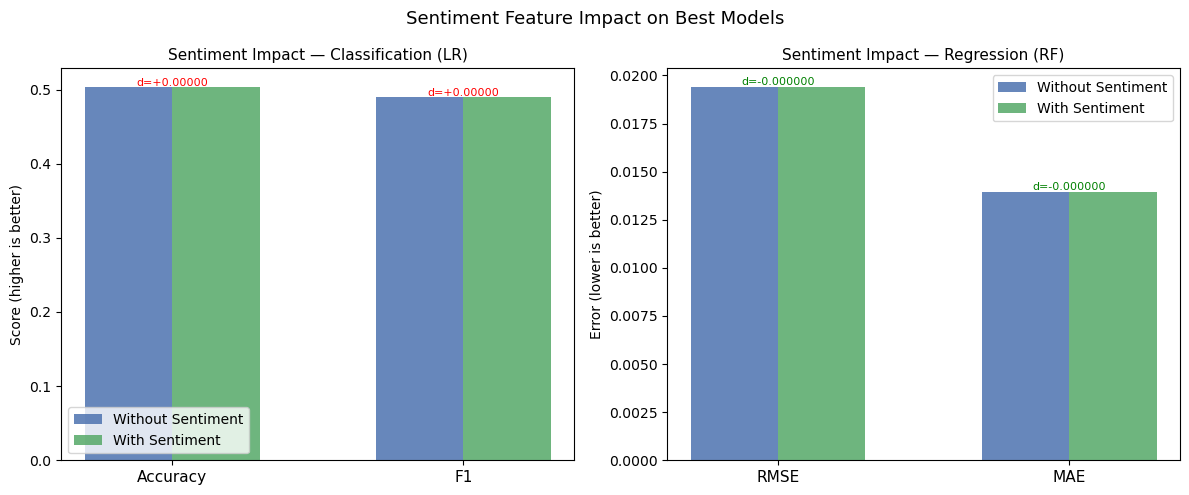

Notebook 06 complete — sentiment results saved.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
width = 0.3

x      = np.arange(2)
wo_clf = [clf_wo["Accuracy"], clf_wo["F1"]]
wi_clf = [clf_wi["Accuracy"], clf_wi["F1"]]
axes[0].bar(x - width/2, wo_clf, width, label="Without Sentiment", color="#4C72B0", alpha=0.85)
axes[0].bar(x + width/2, wi_clf, width, label="With Sentiment",    color="#55A868", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(["Accuracy", "F1"], fontsize=11)
axes[0].set_title("Sentiment Impact — Classification (LR)", fontsize=11)
axes[0].set_ylabel("Score (higher is better)")
axes[0].legend()
for i, (wo, wi) in enumerate(zip(wo_clf, wi_clf)):
    delta = wi - wo
    axes[0].text(i, max(wo, wi) + 0.001, f"d={delta:+.5f}",
                 ha="center", fontsize=8, color="green" if delta > 0 else "red")

wo_reg = [reg_wo["RMSE"], reg_wo["MAE"]]
wi_reg = [reg_wi["RMSE"], reg_wi["MAE"]]
axes[1].bar(x - width/2, wo_reg, width, label="Without Sentiment", color="#4C72B0", alpha=0.85)
axes[1].bar(x + width/2, wi_reg, width, label="With Sentiment",    color="#55A868", alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(["RMSE", "MAE"], fontsize=11)
axes[1].set_title("Sentiment Impact — Regression (RF)", fontsize=11)
axes[1].set_ylabel("Error (lower is better)")
axes[1].legend()
for i, (wo, wi) in enumerate(zip(wo_reg, wi_reg)):
    delta = wi - wo
    axes[1].text(i, max(wo, wi) + 0.0001, f"d={delta:+.6f}",
                 ha="center", fontsize=8, color="green" if delta < 0 else "red")

plt.suptitle("Sentiment Feature Impact on Best Models", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "sentiment_impact.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Notebook 06 complete — sentiment results saved.")